In [1]:
import itertools
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import torch.distributions as D
import numpy as np
from numpy.random import default_rng
import pymc3 as pm
from scipy.stats import vonmises
from scipy.special import i0

from insilico_stimuli.stimuli import GaborSet, CenterSurround

seed = 42
rng = default_rng(seed=seed)
torch.manual_seed(seed=seed)
EPSILON = 1e-12
mpl.style.use("seaborn")
sns.set_palette("colorblind")
sns.set_context("paper")
sns.set_style("darkgrid")
mpl.style.use("seaborn")

## Utilities

In [2]:
def plot_correlation(trace):
    fig, ax = plt.subplots(dpi=100)
    sns.heatmap(np.corrcoef(trace["neuron"].T), ax=ax, cmap="seismic")
    # make it a square plot
    ax.set_aspect("equal")
    # reduce the tick size
    ax.tick_params(axis="both", which="major", labelsize=9)

In [3]:
def vonmises_pdf(x, mu, kappa):
    return np.exp(kappa * np.cos(x - mu)) / (2 * np.pi * i0(kappa))

In [4]:
def plot_samples(trace, gabors, orientations):
    # share x only for 1st row of subplots
    fig, axs = plt.subplots(nrows=4, ncols=6, dpi=200)  # , sharex="row", sharey="row")
    for idx, ax in enumerate(axs[::2].ravel()):
        response = trace["neuron"][:, idx]
        response_mean = np.mean(trace["neuron"][:, idx].ravel())
        color = "blue" if response_mean < 0.3 else "red"
        sns.histplot(
            response.ravel(), color=color, stat="probability", element="step", ax=ax
        )
        ax.text(0.05, 0.95, idx + 1, fontsize=4, transform=ax.transAxes)
        ax.text(0.5, 0.95, f"{response_mean:.2f}", fontsize=4, transform=ax.transAxes)
        ax.text(
            0.95,
            0.95,
            f"{int(np.rad2deg(orientations[idx]))}$^\circ$",
            fontsize=4,
            transform=ax.transAxes,
        )
        ax.tick_params(axis="both", which="major", labelsize=5)
        # reduce the font size of the x and y labels
        ax.axis("off")
        # ax.xaxis.label.set_size(5)
        # ax.yaxis.label.set_size(5)
    for idx, ax in enumerate(axs[1::2].ravel()):
        ax.imshow(gabors[idx], cmap="gray", vmin=-1, vmax=1)
        ax.axis("off")

## Create Projective Fields of neurons (PFs)

In [5]:
gabor_locations = [(10, 25), (25, 25), (40, 25)]
gabor_params = {
    "canvas_size": [50, 50],
    "sizes": [15],
    "spatial_frequencies": [1 / 20],
    "contrasts": [1.0],
    "grey_levels": [0.0],
    "eccentricities": [0.0],
    "locations": gabor_locations,
    "orientations": [0.0, np.pi / 2],
    "phases": [np.pi / 2, 0.0],
    "relative_sf": False,
}

gabor_set = GaborSet(**gabor_params)

In [6]:
total_param_count = np.prod(gabor_set.num_params())
param_combos = [gabor_set.params_dict_from_idx(idx) for idx in range(total_param_count)]
valid_params_gabors = [
    (param_combos[idx], gabor_set.stimulus_from_idx(idx))
    for idx in range(total_param_count)
    # if not (
    #     (param_combos[idx]["orientation"] == np.pi/2 and param_combos[idx]["phase"] == 0.)
    #     or
    #     (param_combos[idx]["orientation"] == 0. and param_combos[idx]["location"] == (25, 25))
    # or
    # (param_combos[idx]["orientation"] == 0. and param_combos[idx]["phase"] == np.pi/2 and param_combos[idx]["location"] == (40, 25))
    # or
    # (param_combos[idx]["orientation"] == 0. and param_combos[idx]["phase"] == 0. and param_combos[idx]["location"] == (10, 25))
    # )
]
valid_params_gabors = sorted(valid_params_gabors, key=lambda x: x[0]["orientation"])
valid_gabors = np.array([gabor for _, gabor in valid_params_gabors])
valid_orientations = np.array(
    [param["orientation"] for param, _ in valid_params_gabors]
)

In [7]:
print(f"Number of valid gabors: {len(valid_gabors)}"), print(
    f"Number of valid orientations: {len(valid_orientations)}"
)

Number of valid gabors: 12
Number of valid orientations: 12


(None, None)

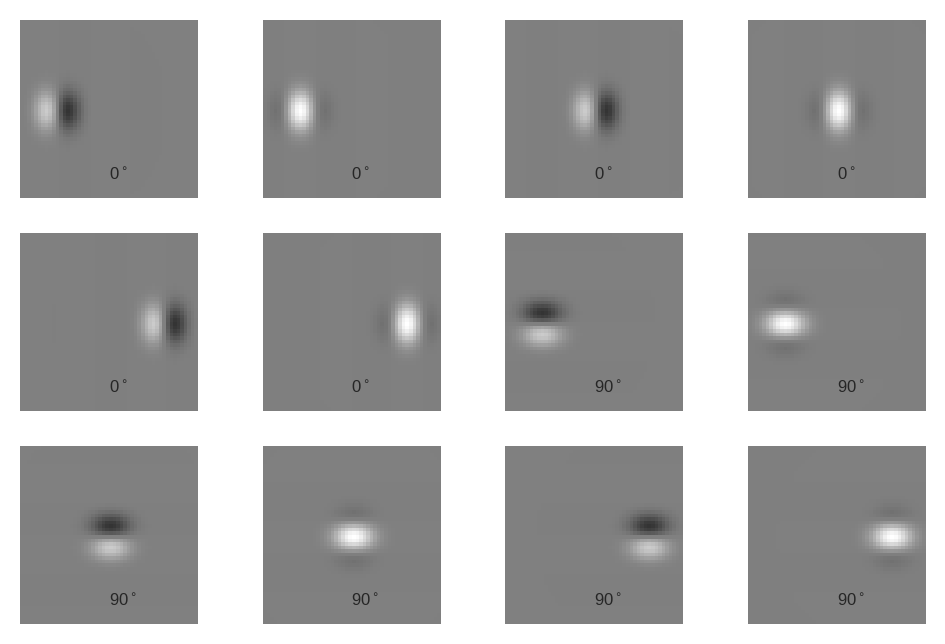

In [8]:
fig, axs = plt.subplots(nrows=3, ncols=4, dpi=200)
for idx, ax in enumerate(axs.ravel()):
    gabor = valid_gabors[idx]
    orientation = valid_orientations[idx]
    ax.imshow(gabor, cmap="gray", vmin=-1, vmax=1)
    ax.text(
        0.5,
        0.1,
        f"{int(np.rad2deg(orientation))}$^\circ$",
        transform=ax.transAxes,
        fontsize=6,
    )
    ax.axis("off")

## Create posterior sampling `pymc` model

In [9]:
def sample_posterior(stimulus, vonmises_kappa=5.0, n_samples=1000):
    vonmises_loc = 0.0
    n_neurons = len(valid_gabors)
    stimulus_sigma = torch.abs(torch.rand(1)) + EPSILON
    model = pm.Model()
    with model:
        o = pm.Uniform("orientation", lower=-np.pi / 2, upper=np.pi)
        z = pm.Exponential(
            "neuron",
            lam=vonmises_pdf(o - valid_orientations, vonmises_loc, vonmises_kappa),
            shape=n_neurons,
        )
        x = pm.Normal(
            "stimulus",
            mu=torch.tensor(valid_gabors).permute(1, 2, 0) @ z,
            sigma=stimulus_sigma,
            observed=stimulus,
        )
        trace = pm.sample(n_samples, return_inferencedata=False)
    return trace

# Present center surround stimulus

## First a center-PF as stimulus

(-0.5, 49.5, 49.5, -0.5)

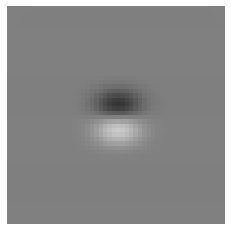

In [10]:
center_PF = valid_gabors[8]
plt.imshow(center_PF, cmap="gray", vmin=-1, vmax=1)
plt.axis("off")

In [11]:
center_trace = sample_posterior(center_PF)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [neuron, orientation]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


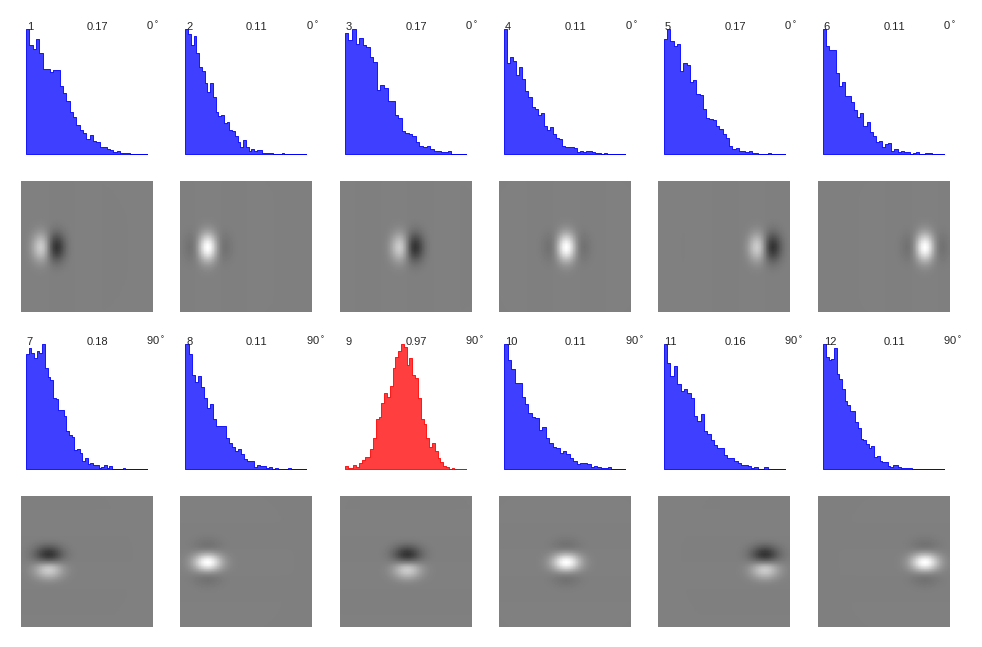

In [12]:
plot_samples(center_trace, valid_gabors, valid_orientations)

In [13]:
center_trace["orientation"].mean()

0.7757097438855142

## Now a circle-cut center-PF

(-0.5, 49.5, 49.5, -0.5)

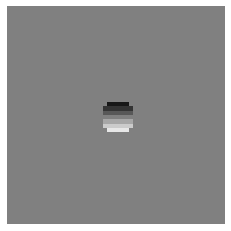

In [14]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": [1 / 20],
    "spatial_frequencies_surround": [1 / 10],
    "phases_center": [np.pi / 2],
    "phases_surround": [np.pi / 2],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [np.pi / 2],
    "orientations_surround": [np.pi / 2],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [15 / 4 / 50],
    "sizes_surround": [15 / 4 / 50],
    "contrasts_center": [1.0],
    "contrasts_surround": [0.0],
}

circle_center_PF = CenterSurround(**center_surround_params).images()[0]
plt.imshow(circle_center_PF, cmap="gray", vmin=-1, vmax=1)
plt.axis("off")

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [neuron, orientation]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.


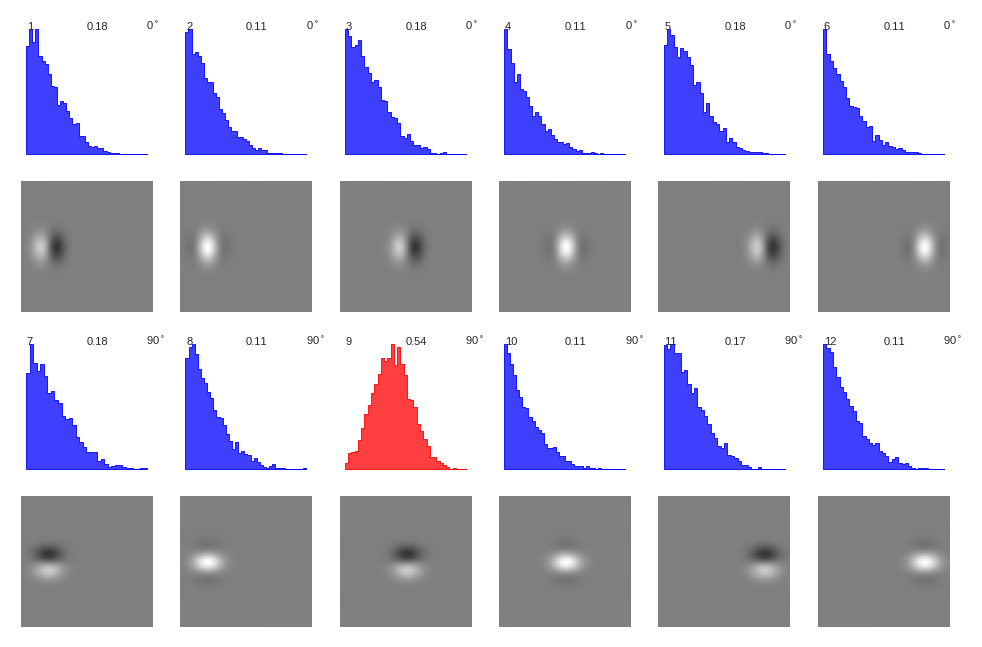

In [15]:
circle_center_trace = sample_posterior(circle_center_PF)
plot_samples(circle_center_trace, valid_gabors, valid_orientations)

In [16]:
circle_center_trace["orientation"].mean()

0.7812440516158872

## Now present congruent center-surround stimulus

(-0.5, 49.5, 49.5, -0.5)

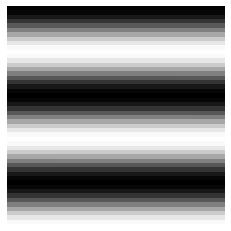

In [17]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": [1 / 20],
    "spatial_frequencies_surround": [1 / 20],
    "phases_center": [np.pi / 2],
    "phases_surround": [np.pi / 2],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [np.pi / 2],
    "orientations_surround": [np.pi / 2],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [15 / 4 / 50],
    "sizes_surround": [15 / 4 / 50],
    "contrasts_center": [1.0],
    "contrasts_surround": [1.0],
}

congruent = CenterSurround(**center_surround_params).images()[0]
plt.imshow(congruent, cmap="gray", vmin=-1, vmax=1)
plt.axis("off")

In [18]:
congruent_trace = sample_posterior(congruent)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [neuron, orientation]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


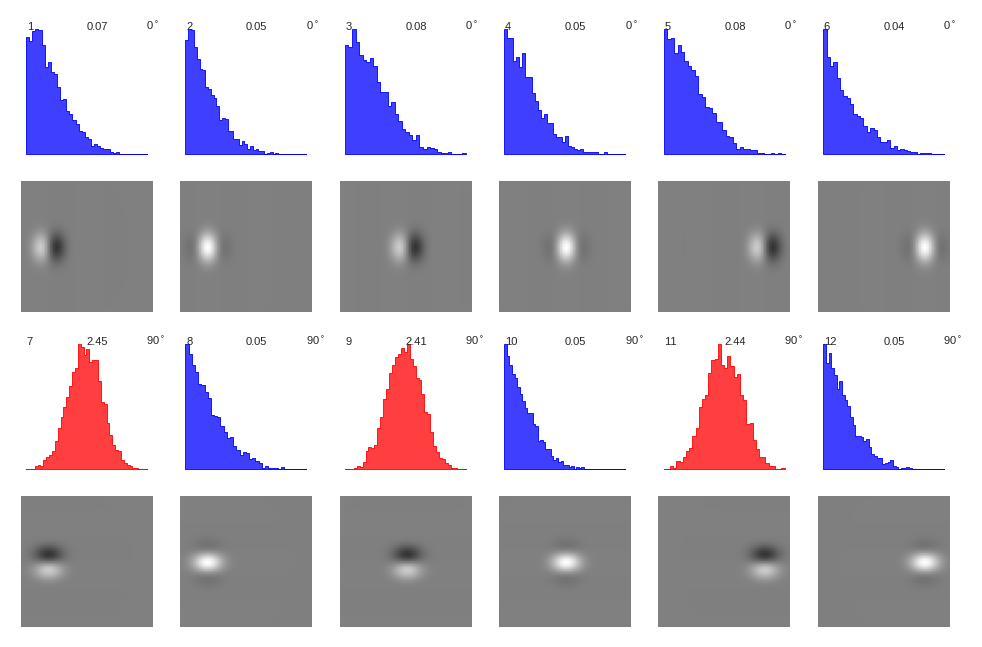

In [19]:
plot_samples(congruent_trace, valid_gabors, valid_orientations)

## Now an incongruent center-surround stimulus

(-0.5, 49.5, 49.5, -0.5)

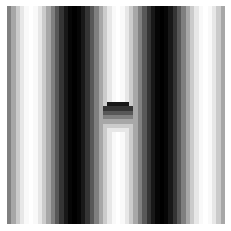

In [20]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": gabor_params["spatial_frequencies"],
    "spatial_frequencies_surround": [1 / 20],
    "phases_center": gabor_params["phases"],
    "phases_surround": [np.pi / 2 + 2 * np.pi * 1 / 20 * (25 - 10)],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [np.pi / 2],
    "orientations_surround": [0.0],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [15 / 4 / 50],
    "sizes_surround": [15 / 4 / 50],
    "contrasts_center": [1.0],
    "contrasts_surround": [1.0],
}

incongruent = CenterSurround(**center_surround_params).images()[0]
plt.imshow(incongruent, cmap="gray", vmin=-1, vmax=1)
plt.axis("off")

In [21]:
incongruent_trace = sample_posterior(incongruent)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [neuron, orientation]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.
There were 3 divergences after tuning. Increase `target_accept` or reparameterize.
There were 3 divergences after tuning. Increase `target_accept` or reparameterize.


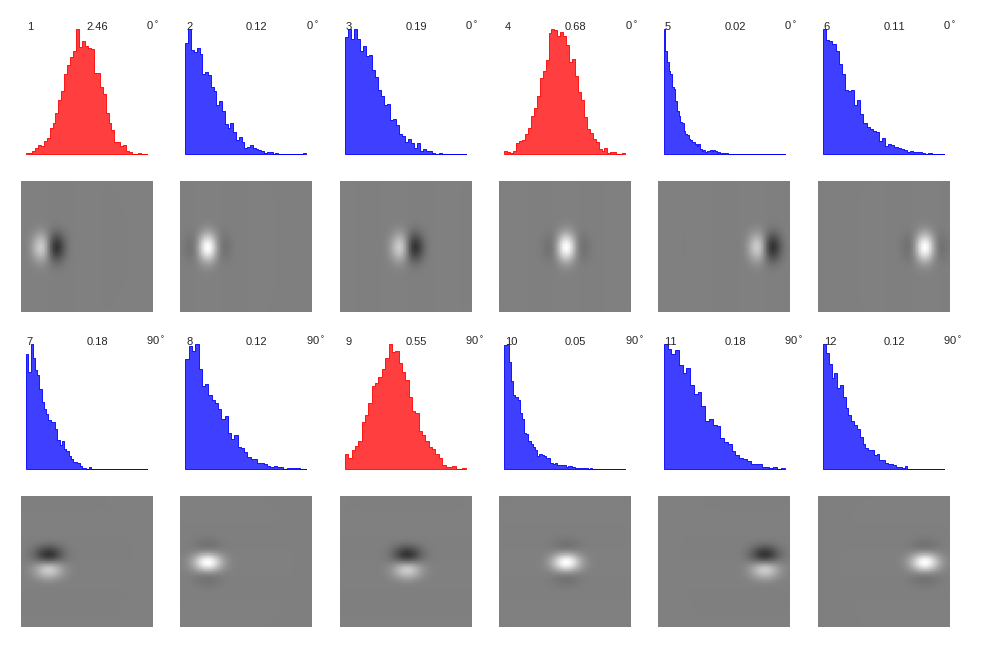

In [22]:
plot_samples(incongruent_trace, valid_gabors, valid_orientations)

(-0.5, 49.5, 49.5, -0.5)

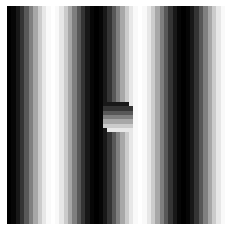

In [23]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": gabor_params["spatial_frequencies"],
    "spatial_frequencies_surround": [1 / 20],
    "phases_center": gabor_params["phases"],
    "phases_surround": [np.pi / 2 + 2 * np.pi * 1 / 20 * (10 - 40)],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [np.pi / 2],
    "orientations_surround": [0.0],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [15 / 4 / 50],
    "sizes_surround": [15 / 4 / 50],
    "contrasts_center": [1.0],
    "contrasts_surround": [1.0],
}

incongruent_2 = CenterSurround(**center_surround_params).images()[0]
plt.imshow(incongruent_2, cmap="gray", vmin=-1, vmax=1)
plt.axis("off")

# decresed center as well??? also look at the inferred global orientation. look at the firing rates of the exponential distribution

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [neuron, orientation]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
There were 3 divergences after tuning. Increase `target_accept` or reparameterize.


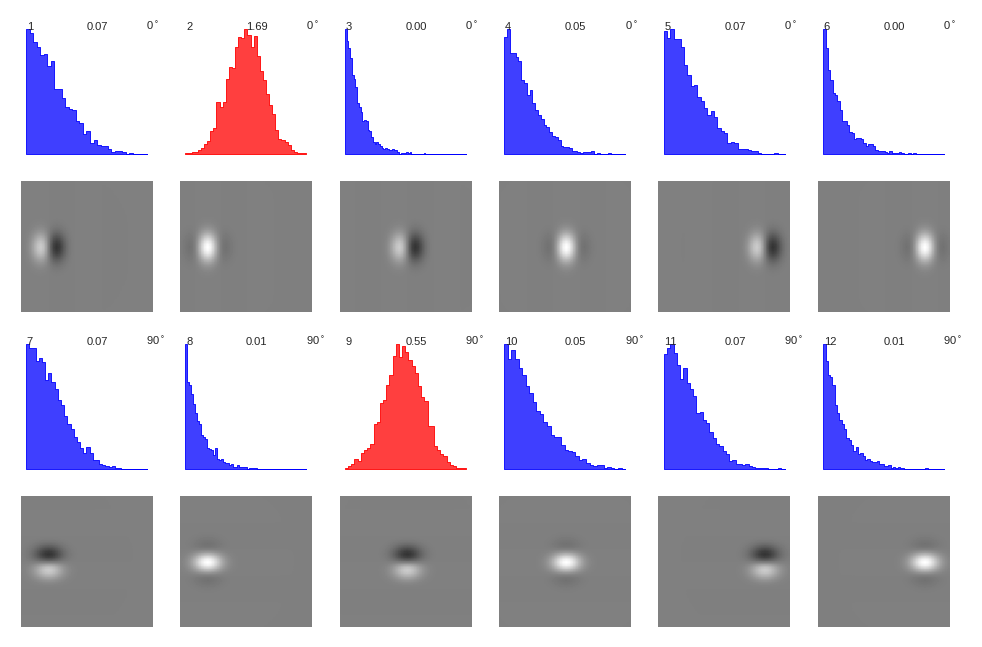

In [24]:
incongruent_2_trace = sample_posterior(incongruent_2)
plot_samples(incongruent_2_trace, valid_gabors, valid_orientations)

## Surround only

(-0.5, 49.5, 49.5, -0.5)

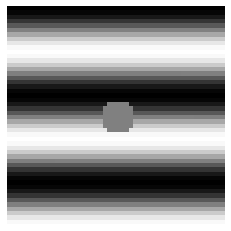

In [25]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": [1 / 20],
    "spatial_frequencies_surround": [1 / 20],
    "phases_center": [np.pi / 2],
    "phases_surround": [np.pi / 2],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [np.pi / 2],
    "orientations_surround": [np.pi / 2],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [15 / 4 / 50],
    "sizes_surround": [15 / 4 / 50],
    "contrasts_center": [0.0],
    "contrasts_surround": [1.0],
}

surround_only = CenterSurround(**center_surround_params).images()[0]
plt.imshow(surround_only, cmap="gray", vmin=-1, vmax=1)
plt.axis("off")

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [neuron, orientation]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.


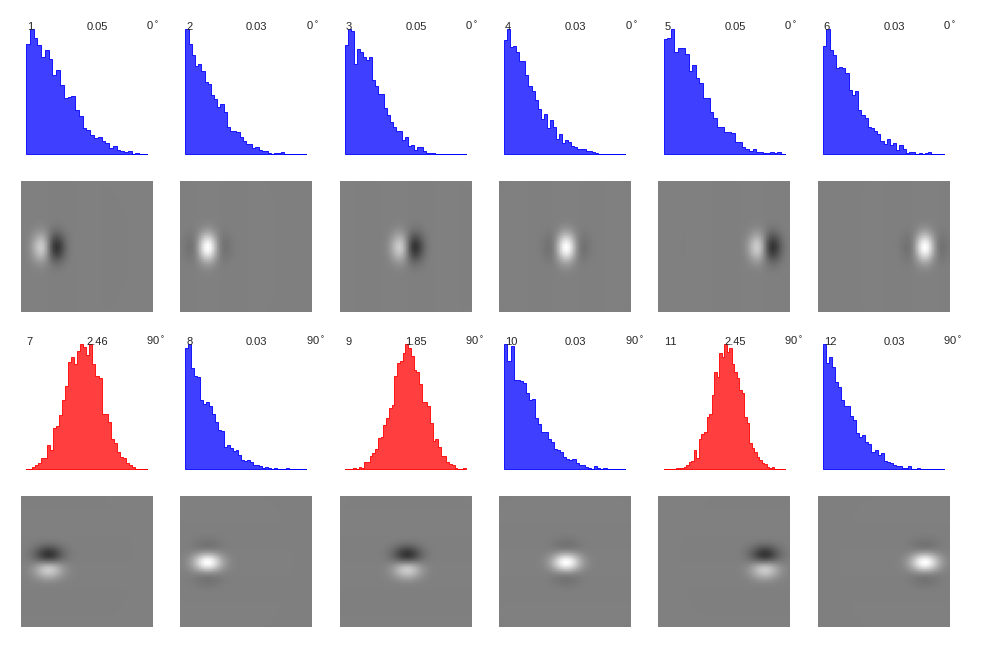

In [27]:
surround_only_trace = sample_posterior(surround_only)
plot_samples(surround_only_trace, valid_gabors, valid_orientations)

## Moat-surround only

In [ ]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": [1 / 20],
    "spatial_frequencies_surround": [1 / 20],
    "phases_center": [np.pi / 2],
    "phases_surround": [np.pi / 2],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [np.pi / 2],
    "orientations_surround": [np.pi / 2],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [15 / 4 / 50],
    "sizes_surround": [25 / 4 / 50],
    "contrasts_center": [0.0],
    "contrasts_surround": [1.0],
}

surround_moat = CenterSurround(**center_surround_params).images()[0]
plt.imshow(surround_moat, cmap="gray", vmin=-1, vmax=1)
plt.axis("off")

In [ ]:
surround_moat_trace = sample_posterior(surround_moat)
plot_samples(surround_moat_trace, valid_gabors, valid_orientations)

NameError: name 'surround_moat_trace' is not defined

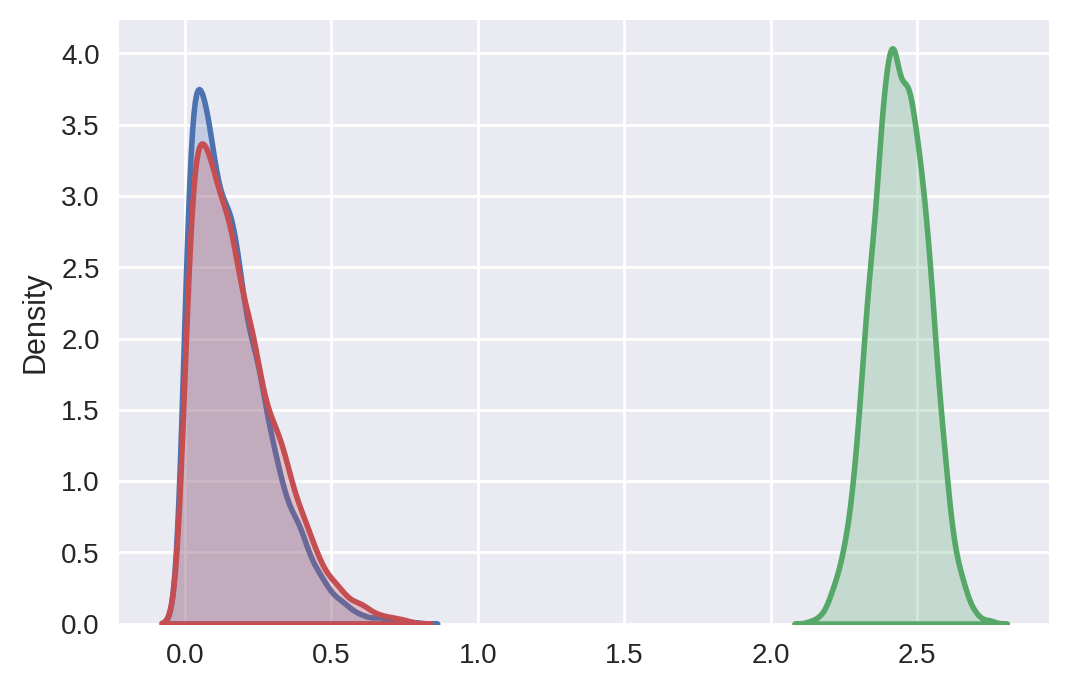

In [28]:
# plot a seaborn histogram using kdeplot for all traces with labels
# fill the kde plots with the same color
fig, ax = plt.subplots(dpi=200)
sns.kdeplot(center_trace["neuron"][:, -2].ravel(), linewidth=2, shade=True, label="MEI")
sns.kdeplot(
    congruent_trace["neuron"][:, -2].ravel(), linewidth=2, shade=True, label="Congruent"
)
sns.kdeplot(
    incongruent_trace["neuron"][:, -2].ravel(),
    linewidth=2,
    shade=True,
    label="Incongruent",
)
# sns.kdeplot(surround_only_trace["neuron"][:, -2].ravel(), linewidth=2, shade=True, label="Surround only")
sns.kdeplot(
    surround_moat_trace["neuron"][:, -2].ravel(),
    linewidth=2,
    shade=True,
    label="Surround moat",
)
sns.kdeplot(center_trace["neuron"][:, 0].ravel(), linewidth=2, shade=True, label="Base")
# label the x axis with "firing rate"
ax.set_xlabel("Mean firing rate")
# move the legend to the top center
plt.legend(prop={"size": 10}, title="Stimulus", title_fontsize=12, loc="upper center")

In [ ]:
# Festa et al reference, sampling not needed, just posterior coding (read up Lange, Haefner. Mumford and Lee)

In [ ]:
fig, ax = plt.subplots(dpi=100)
center_PF.std(), congruent.std(), incongruent.std(), surround_moat.std()
# plot the above stds as a seaborn bar plot
sns.barplot(
    x=["MEI", "Congruent", "Incongruent", "Surround moat"],
    y=[center_PF.std(), congruent.std(), incongruent.std(), surround_moat.std()],
    ax=ax,
)

In [ ]:
congruent_contrast_rescaled = congruent.std() / center_PF.std()

In [ ]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": [1 / 20],
    "spatial_frequencies_surround": [1 / 20],
    "phases_center": [np.pi / 2],
    "phases_surround": [np.pi / 2],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [np.pi / 2],
    "orientations_surround": [np.pi / 2],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [15 / 4 / 50],
    "sizes_surround": [15 / 4 / 50],
    "contrasts_center": [congruent_contrast_rescaled],
    "contrasts_surround": [congruent_contrast_rescaled],
}

congruent_contrast_rescaled_img = CenterSurround(**center_surround_params).images()[0]
plt.imshow(congruent_contrast_rescaled_img, cmap="gray", vmin=-1, vmax=1)
plt.axis("off")